# k-Random Walkers with XOR Distance

C: replicas ($C=8$)  
d: neighbors (d=20)  
N: network size  
k: walker steps  
h: walker hops (TTL)  
$\gamma$: path correlation penalty (proportional to $\beta$)
$$P_{\text{success}} \approx 1 - \left( 1 - \frac{C \cdot (d + 1)}{N} \right)^{h \cdot (k \cdot \gamma)}$$

In [10]:
import networkx as nx
import numpy as np
import random
import math
from collections import defaultdict

def build_unstructured_network(num_nodes=50000, degree=20):
    """
    Creates a random regular graph where every node has exactly 'degree' peers.
    This models a massive, unstructured decentralized ring perfectly.
    """
    return nx.random_regular_graph(degree, num_nodes)

def assign_256bit_ids(G):
    """Assigns a random 256-bit integer ID to every node in the graph."""
    return {node: random.getrandbits(256) for node in G.nodes()}

def scaled_xor_distance(node_id, cid):
    """
    Calculates the XOR distance and scales it using log2 to prevent 
    floating-point underflow in the exponential biasing function.
    """
    xor_result = node_id ^ cid
    if xor_result == 0:
        return 0
    return math.log2(xor_result) # Scales distances from 0 to 256

def biased_xor_step(G, current_node, node_ids, cid, beta, visited):
    """
    Calculates transition probabilities based on the scaled XOR distance to the CID,
    strictly ignoring any nodes that have already been visited.
    """
    # Filter out already visited nodes
    unvisited_neighbors = [n for n in G.neighbors(current_node) if n not in visited]
    
    # Handle the Dead End edge case: if all neighbors are visited, the walker dies
    if not unvisited_neighbors:
        return None 
    
    # Calculate log2-scaled distances ONLY for unvisited neighbors
    distances = [scaled_xor_distance(node_ids[n], cid) for n in unvisited_neighbors]
    
    if beta == np.inf:
        # Pure greedy: pick the neighbor with the smallest distance
        min_index = np.argmin(distances)
        return unvisited_neighbors[min_index]

    # Apply exponential bias: e^(-beta * scaled_distance)
    min_dist = min(distances)
    weights = [np.exp(-beta * (d - min_dist)) for d in distances]
    
    total_weight = sum(weights)
    if total_weight == 0 or not math.isfinite(total_weight):
        return random.choice(unvisited_neighbors) 
        
    probabilities = [w / total_weight for w in weights]
    
    # Choose next node
    return np.random.choice(unvisited_neighbors, p=probabilities)

def simulate_k_walkers_concurrent(G, start_node, target_node, node_ids, cid, beta, k, h):
    """
    Simulates k walkers searching concurrently to accurately measure latency.
    Returns: (Success Boolean, Total Overhead, Latency)
    """
    total_overhead = 0
    
    # Initialize state for all k walkers
    # Each walker tracks its current node, its personal visited cache, and if it's still alive
    walkers = [
        {'current': start_node, 'visited': {start_node}, 'active': True} 
        for _ in range(k)
    ]
    
    # Simulate step-by-step time passing
    for step in range(1, h + 1):
        for w in walkers:
            if not w['active']:
                continue # Skip dead-end walkers
            
            # Walker takes a step using the self-avoiding XOR logic
            next_node = biased_xor_step(G, w['current'], node_ids, cid, beta, w['visited'])
            
            if next_node is None:
                w['active'] = False # Hit a dead end
                continue
            
            total_overhead += 1
            w['visited'].add(next_node)
            w['current'] = next_node
            
            if next_node == target_node:
                # Target found! The current 'step' is our latency.
                return True, total_overhead, step
        
        # If all walkers hit dead ends early, break the loop
        if not any(w['active'] for w in walkers):
            break
            
    return False, total_overhead, 0

def run_xor_simulation(G, node_ids, iterations=50):
    nodes = list(G.nodes())
    
    betas = [0.1, 0.5, 1.0, 2.0, np.inf]
    walker_counts = [5, 15, 30, 50] 
    ttls = [50, 100, 200, 300, 500]       
    
    # Updated table header
    print(f"{'Beta':<5} | {'k':<4} | {'TTL (h)':<7} | {'Success Rate':<13} | {'Avg Overhead':<13} | {'Avg Latency'}")
    print("-" * 70)

    for beta in betas:
        for k in walker_counts:
            for h in ttls:
                successes = 0
                total_overhead = 0
                total_latency = 0
                
                for _ in range(iterations):
                    target_node = random.choice(nodes)
                    cid = node_ids[target_node] 
                    
                    start_node = random.choice(nodes)
                    while start_node == target_node:
                        start_node = random.choice(nodes)
                        
                    # Run the concurrent simulation
                    success, overhead, latency = simulate_k_walkers_concurrent(
                        G, start_node, target_node, node_ids, cid, beta, k, h
                    )
                    
                    if success:
                        successes += 1
                        total_latency += latency # Only count latency for successful reads
                    total_overhead += overhead
                
                success_rate = successes / iterations
                avg_overhead = total_overhead / iterations
                
                # Handle edge case where success rate is 0 to avoid division by zero
                avg_latency = (total_latency / successes) if successes > 0 else float('inf')
                
                # Format to 1 decimal place for readability
                if avg_latency != float('inf'):
                    print(f"{beta:<5} | {k:<4} | {h:<7} | {success_rate:<13.0%} | {avg_overhead:<13.1f} | {avg_latency:.1f}")
                else:
                    print(f"{beta:<5} | {k:<4} | {h:<7} | {success_rate:<13.0%} | {avg_overhead:<13.1f} | {'N/A'}")

if __name__ == "__main__":
    print("Generating 50,000 node network (degree=20)...")
    uvr_graph = build_unstructured_network(num_nodes=50000, degree=20)
    
    print("Assigning 256-bit random IDs...")
    ids = assign_256bit_ids(uvr_graph)
    
    print("Running XOR routing simulation...\n")
    run_xor_simulation(uvr_graph, ids, iterations=50)

Generating 50,000 node network (degree=20)...
Assigning 256-bit random IDs...
Running XOR routing simulation...

Beta  | k    | TTL (h) | Success Rate  | Avg Overhead  | Avg Latency
----------------------------------------------------------------------
0.1   | 5    | 50      | 8%            | 240.0         | 25.5
0.1   | 5    | 100     | 18%           | 444.4         | 38.6
0.1   | 5    | 200     | 30%           | 853.8         | 103.0
0.1   | 5    | 300     | 52%           | 1086.8        | 141.5
0.1   | 5    | 500     | 58%           | 1694.4        | 222.7
0.1   | 15   | 50      | 24%           | 672.3         | 28.9
0.1   | 15   | 100     | 56%           | 1062.2        | 48.4
0.1   | 15   | 200     | 62%           | 1882.4        | 80.4
0.1   | 15   | 300     | 90%           | 1831.2        | 102.8
0.1   | 15   | 500     | 90%           | 2772.1        | 150.2
0.1   | 30   | 50      | 44%           | 1157.6        | 24.5
0.1   | 30   | 100     | 68%           | 1810.9        | 42.

# Attenuated Bloomfilters

In [13]:
import networkx as nx
import random
import math
from collections import deque

def build_random_network(num_nodes=10000, degree=20):
    """Builds a purely random unstructured graph."""
    return nx.random_regular_graph(degree, num_nodes)

def calculate_abf_metrics(m_mb, n_files, d_max, degree):
    """
    Calculates the mathematical False Positive Rate (P_fp) 
    and the total Memory Overhead per node.
    """
    m_bits = m_mb * 8 * 1024 * 1024
    
    # False positive probability: p = (1 - e^(-kn/m))^k
    # Optimal k = (m/n) * ln(2)
    k = (m_bits / n_files) * math.log(2)
    p_fp = (1 - math.exp(-k * n_files / m_bits)) ** k
    
    # Total memory per node (MB) = degree * d_max * filter_size_mb
    memory_mb = degree * d_max * m_mb
    
    return p_fp, memory_mb

def precompute_true_distances(G, targets):
    """
    Simulates omniscient knowledge of where the files actually are.
    Used exclusively to determine if a Bloom filter should return a True Positive.
    """
    distances = {node: float('inf') for node in G.nodes()}
    queue = deque()
    
    for t in targets:
        distances[t] = 0
        queue.append(t)
        
    while queue:
        current = queue.popleft()
        dist = distances[current]
        
        for neighbor in G.neighbors(current):
            if distances[neighbor] == float('inf'):
                distances[neighbor] = dist + 1
                queue.append(neighbor)
                
    return distances

def simulate_abf_routing(G, start_node, distances, d_max, p_fp):
    """
    Simulates a walker following the Bloom filter scent trail.
    If it hits a False Positive dead end, it backtracks.
    """
    stack = [start_node]
    visited = set([start_node])
    hops = 0
    
    while stack:
        current = stack[-1]
        
        # Target found!
        if distances[current] == 0:
            return True, hops
            
        hops += 1
        stepped = False
        
        # Check radar depths from 1 up to d_max
        for depth in range(1, d_max + 1):
            candidates = []
            for neighbor in G.neighbors(current):
                if neighbor in visited: 
                    continue
                
                # True Positive: The file is physically down this path
                if distances[neighbor] <= depth:
                    candidates.append(neighbor)
                # False Positive: The filter lies based on P_fp
                elif random.random() < p_fp:
                    candidates.append(neighbor)
            
            if candidates:
                # The walker takes the scent trail
                next_node = random.choice(candidates)
                visited.add(next_node)
                stack.append(next_node)
                stepped = True
                break # Break out of the depth loop to take the step
                
        # If no filters matched at any depth, we hit a dead end
        if not stepped:
            stack.pop() # Backtrack one hop
            
    return False, hops

def run_abf_sweep(G, num_nodes, iterations=200):
    # Network Constraints
    capacity_files = 100000 
    d_max = 3
    degree = 20
    num_replicas = 8
    
    # Filter sizes to test in Megabytes (MB)
    filter_sizes = [0.1, 0.25, 0.5, 1.0, 2.0]
    
    print(f"{'Single Filter':<15} | {'Node Memory':<13} | {'False Pos %':<12} | {'Avg Overhead'}")
    print("-" * 60)
    
    for m_mb in filter_sizes:
        p_fp, memory_mb = calculate_abf_metrics(m_mb, capacity_files, d_max, degree)
        
        total_hops = 0
        nodes_list = list(G.nodes())
        
        for _ in range(iterations):
            # 1. Randomly drop 8 replicas in the unstructured network
            targets = random.sample(nodes_list, num_replicas)
            
            # 2. Precompute true shortest paths for the simulation logic
            distances = precompute_true_distances(G, targets)
            
            # 3. Random start node
            start_node = random.choice(nodes_list)
            while start_node in targets:
                start_node = random.choice(nodes_list)
                
            # 4. Route the Read request
            success, hops = simulate_abf_routing(G, start_node, distances, d_max, p_fp)
            total_hops += hops
            
        avg_hops = total_hops / iterations
        print(f"{m_mb:<12} MB | {memory_mb:<10.1f} MB | {p_fp:<12.2%} | {avg_hops:.1f} hops")

if __name__ == "__main__":
    N = [100, 500, 1000, 5000, 10000, 25000, 50000, 100000]
    
    for n in N:
        print(f"Generating {n}-node random unstructured network...")
        uvr_graph = build_random_network(num_nodes=n, degree=20)
        
        print("Running ABF parameter sweep...\n")
        run_abf_sweep(uvr_graph, num_nodes=n, iterations=200)

Generating 100-node random unstructured network...
Running ABF parameter sweep...

Single Filter   | Node Memory   | False Pos %  | Avg Overhead
------------------------------------------------------------
0.1          MB | 6.0        MB | 1.78%        | 7.7 hops
0.25         MB | 15.0       MB | 0.00%        | 8.3 hops
0.5          MB | 30.0       MB | 0.00%        | 7.8 hops
1.0          MB | 60.0       MB | 0.00%        | 7.6 hops
2.0          MB | 120.0      MB | 0.00%        | 9.0 hops
Generating 500-node random unstructured network...
Running ABF parameter sweep...

Single Filter   | Node Memory   | False Pos %  | Avg Overhead
------------------------------------------------------------
0.1          MB | 6.0        MB | 1.78%        | 5.4 hops
0.25         MB | 15.0       MB | 0.00%        | 5.3 hops
0.5          MB | 30.0       MB | 0.00%        | 5.1 hops
1.0          MB | 60.0       MB | 0.00%        | 5.1 hops
2.0          MB | 120.0      MB | 0.00%        | 5.7 hops
Generati

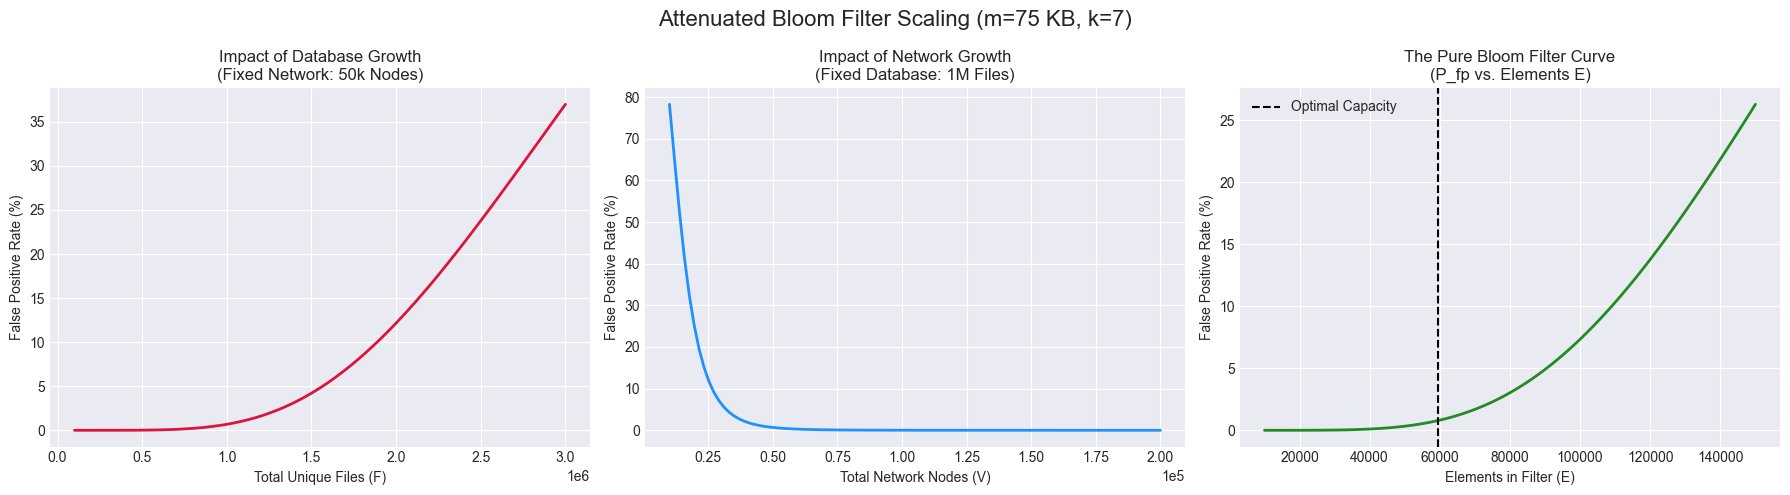

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. System Constants ---
D = 20          # Node degree (peers)
R = 8           # Number of replicas per file
depth = 3       # Looking at the deepest filter (BF_3)
nodes_covered = (D - 1)**(depth - 1) # ~361 nodes in a 3-hop branch

# --- 2. Filter Constraints ---
# We use a highly optimized ~73 KB filter to make the curves visible
m_bits = 600_000 
k_hashes = 7

# Baseline values for the hold-steady variables
V_baseline = 50_000      # 50k nodes
F_baseline = 1_000_000   # 1 Million files

# --- 3. Mathematical Functions ---
def calculate_elements(F, V):
    """Calculates E: The actual number of file chunks inside the BF_3 filter."""
    files_per_node = (F * R) / V
    return nodes_covered * files_per_node

def calculate_pfp(E, m, k):
    """Calculates the False Positive Rate based on inserted elements E."""
    # Using np.exp for vectorized array calculations
    return (1 - np.exp(-k * E / m))**k

# --- 4. Generate Data Arrays ---
# Scenario A: Database grows, Network stays at 50k nodes
F_array = np.linspace(100_000, 3_000_000, 100)
E_scenario_A = calculate_elements(F_array, V_baseline)
Pfp_scenario_A = calculate_pfp(E_scenario_A, m_bits, k_hashes)

# Scenario B: Network grows, Database stays at 1 Million files
V_array = np.linspace(10_000, 200_000, 100)
E_scenario_B = calculate_elements(F_baseline, V_array)
Pfp_scenario_B = calculate_pfp(E_scenario_B, m_bits, k_hashes)

# Scenario C: The Pure Mathematical Bloom Filter Curve
E_array = np.linspace(10_000, 150_000, 100)
Pfp_scenario_C = calculate_pfp(E_array, m_bits, k_hashes)

# --- 5. Plotting ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Attenuated Bloom Filter Scaling (m={m_bits/8000:.0f} KB, k={k_hashes})', fontsize=16)

# Plot 1: P_fp vs Total Files (F)
axes[0].plot(F_array, Pfp_scenario_A * 100, color='crimson', linewidth=2)
axes[0].set_title('Impact of Database Growth\n(Fixed Network: 50k Nodes)')
axes[0].set_xlabel('Total Unique Files (F)')
axes[0].set_ylabel('False Positive Rate (%)')
axes[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# Plot 2: P_fp vs Network Size (V)
axes[1].plot(V_array, Pfp_scenario_B * 100, color='dodgerblue', linewidth=2)
axes[1].set_title('Impact of Network Growth\n(Fixed Database: 1M Files)')
axes[1].set_xlabel('Total Network Nodes (V)')
axes[1].set_ylabel('False Positive Rate (%)')
axes[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# Plot 3: P_fp vs Filter Elements (E)
axes[2].plot(E_array, Pfp_scenario_C * 100, color='forestgreen', linewidth=2)
axes[2].set_title('The Pure Bloom Filter Curve\n(P_fp vs. Elements E)')
axes[2].set_xlabel('Elements in Filter (E)')
axes[2].set_ylabel('False Positive Rate (%)')
axes[2].axvline(x=(m_bits/k_hashes)*np.log(2), color='black', linestyle='--', label='Optimal Capacity')
axes[2].legend()

plt.tight_layout()
plt.show()

# Hybrid Topology with 1D-Ring

In [11]:
import networkx as nx
import random

MAX_ID = 2**256

def circular_distance(id1, id2):
    """Calculates the shortest distance around the 1D circular number line."""
    diff = abs(id1 - id2)
    return min(diff, MAX_ID - diff)

def build_hybrid_ring(num_nodes=50000, total_degree=20):
    """
    Builds a hybrid topology: a strict 1D base ring for guaranteed routing,
    plus purely random long-range connections for unstructured resilience.
    """
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    
    # 1. Build the Safety Net (The Base 1D Ring)
    for i in range(num_nodes):
        G.add_edge(i, (i + 1) % num_nodes)
        
    # 2. Add the Random Fast Lanes
    # We want each node to reach roughly 'total_degree' edges
    random_edges_needed = (total_degree - 2) * num_nodes // 2
    
    edges_added = 0
    while edges_added < random_edges_needed:
        u = random.randint(0, num_nodes - 1)
        v = random.randint(0, num_nodes - 1)
        
        # Avoid self-loops and duplicate edges
        if u != v and not G.has_edge(u, v):
            G.add_edge(u, v)
            edges_added += 1
            
    return G

def get_contiguous_replicas(num_nodes, center_node, num_replicas=8):
    """Locates the 8 replicas natively clustered along the 1D gradient."""
    replicas = set()
    offset = 0
    while len(replicas) < num_replicas:
        replicas.add((center_node + offset) % num_nodes)
        if len(replicas) < num_replicas:
            replicas.add((center_node - offset) % num_nodes)
        offset += 1
    return replicas

def strictly_greedy_search(G, start_node, target_nodes, cid, node_ids):
    """
    A single walker always choosing the absolute best 1D distance neighbor.
    Because of the base ring, this will NEVER hit a dead end.
    """
    current = start_node
    hops = 0
    
    while True:
        if current in target_nodes:
            return True, hops
            
        neighbors = list(G.neighbors(current))
        best_neighbor = min(neighbors, key=lambda n: circular_distance(node_ids[n], cid))
        
        current = best_neighbor
        hops += 1

def run_hybrid_simulation(G, node_ids, num_nodes, iterations=1000):
    nodes = list(G.nodes())
    successes = 0
    total_hops = 0
    
    print(f"{'Simulation':<12} | {'k Walkers':<10} | {'Success Rate':<15} | {'Avg Overhead / Latency'}")
    print("-" * 65)

    for _ in range(iterations):
        cid = random.getrandbits(256)
        ideal_node = min(nodes, key=lambda n: circular_distance(node_ids[n], cid))
        target_replicas = get_contiguous_replicas(num_nodes, ideal_node, num_replicas=8)
        
        start_node = random.choice(nodes)
        while start_node in target_replicas:
            start_node = random.choice(nodes)
            
        # Single greedy walker
        success, hops = strictly_greedy_search(G, start_node, target_replicas, cid, node_ids)
        
        if success:
            successes += 1
            total_hops += hops
            
    print(f"{'Hybrid Ring':<12} | {1:<10} | {successes/iterations:<15.0%} | {total_hops/iterations:.1f} hops")

if __name__ == "__main__":
    N = 50000
    
    print(f"Generating {N}-node Hybrid Ring (Degree=20)...")
    uvr_graph = build_hybrid_ring(num_nodes=N, total_degree=20)
    
    # IDs mapped directly to physical ring position
    step = MAX_ID // N
    ids = {i: i * step for i in range(N)}
    
    print("Running greedy routing simulation...\n")
    run_hybrid_simulation(uvr_graph, ids, num_nodes=N, iterations=1000)

Generating 50000-node Hybrid Ring (Degree=20)...
Running greedy routing simulation...

Simulation   | k Walkers  | Success Rate    | Avg Overhead / Latency
-----------------------------------------------------------------
Hybrid Ring  | 1          | 100%            | 42.5 hops


Two Tuple Space layers:
- application layer (permissioned) p2pTS
- storage layer (anyone can contribute) DHT-TS

centralized DHT routes TS (Gateway)

concurrency resolution is not supported by current DHT

Networked Data Representation 
<device ID, data> --> <CID, data>

Storage --> RDMS

lose partition, how do you resynchronize?